In [1]:
!pip install -q boltz biopython matplotlib py3Dmol pyyaml

import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 10.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.4/114.4 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.2/399.2 kB 30.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 98.2 MB/s eta 0:00:00
   ━━

In [6]:

# Downloading sequence from UniProt

import os
import urllib.request

os.makedirs("boltz_input", exist_ok=True)
os.makedirs("boltz_output", exist_ok=True)

# Enter UniProt ID here
UNIPROT_ID = "Q02936"  # Drosophila Hedgehog

# Download FASTA from UniProt
url = f"https://rest.uniprot.org/uniprotkb/{UNIPROT_ID}.fasta"
urllib.request.urlretrieve(url, "raw_sequence.fasta")

# Read and reformat with Boltz-compatible header (no pipes, no special chars)
sequences = []
with open("raw_sequence.fasta") as f:
    header = ""
    seq = ""
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            header = line
            seq = ""
        else:
            seq += line
    sequences.append((header, seq))

# Create clean FASTA for Boltz — simple header, no pipes
# Boltz is very picky: header must be just >SimpleName
clean_name = f"protein_{UNIPROT_ID}"
clean_fasta = f"boltz_input/{clean_name}.fasta"

with open(clean_fasta, "w") as f:
    f.write(f">{clean_name}\n")
    for i in range(0, len(seq), 60):
        f.write(seq[i:i+60] + "\n")

# Remove any old input files that might confuse Boltz
import glob
for old_file in glob.glob("boltz_input/*.fasta"):
    if old_file != clean_fasta:
        os.remove(old_file)

print(f"Downloaded from UniProt: {UNIPROT_ID}")
print(f"Original header: {header[:80]}...")
print(f"Length: {len(seq)} aa")
print(f"Saved as: {clean_fasta}")
print(f"Boltz header: >{clean_name}")

✓ FASTA headers cleaned for Boltz compatibility
  boltz_input/Drosophila_M_HH.fasta: >HH


In [9]:
import time

print("=" * 60)
print("RUNNING BOLTZ-2 STRUCTURE PREDICTION")
print("=" * 60)
print("This may take 2-5 minutes on T4 GPU...\n")

start = time.time()

!boltz predict boltz_input/ --out_dir boltz_output/ --use_msa_server --recycling_steps 3

elapsed = time.time() - start
print(f"\n✓ Prediction complete in {elapsed/60:.1f} minutes")


RUNNING BOLTZ-2 STRUCTURE PREDICTION
This may take 2-5 minutes on T4 GPU...

MSA server enabled: https://api.colabfold.com
MSA server authentication: no credentials provided
Checking input data.
Processing 1 inputs with 1 threads.
  0% 0/1 [00:00<?, ?it/s]Generating MSA for boltz_input/input.yaml with 1 protein entities.
Calling MSA server for target input with 1 sequences
MSA server URL: https://api.colabfold.com
MSA pairing strategy: greedy
No authentication provided for MSA server

  0% 0/150 [00:00<?, ?it/s]
SUBMIT:   0% 0/150 [00:00<?, ?it/s]
COMPLETE:   0% 0/150 [00:00<?, ?it/s]
COMPLETE: 100% 150/150 [00:01<00:00, 77.83it/s] 
100% 1/1 [00:02<00:00,  2.58s/it]
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Running structure prediction for 1 input.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was pro

In [10]:
import py3Dmol
import glob

print("=" * 60)
print("3D VISUALIZATION")
print("=" * 60)

# Find output structure
cif_files = sorted(glob.glob("boltz_output/**/*.cif", recursive=True))
pdb_files = sorted(glob.glob("boltz_output/**/*.pdb", recursive=True))
struct_files = cif_files + pdb_files

if struct_files:
    print(f"Found {len(struct_files)} structure(s)")
    struct_file = struct_files[0]

    with open(struct_file) as f:
        struct_data = f.read()

    fmt = "cif" if struct_file.endswith(".cif") else "pdb"

    view = py3Dmol.view(width=800, height=600)
    view.addModel(struct_data, fmt)
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.addSurface(py3Dmol.VDW, {'opacity': 0.2, 'color': 'white'})
    view.zoomTo()
    view.show()
else:
    print("No output structures found — check boltz_output/ directory")
    !find boltz_output/ -type f

3D VISUALIZATION
Found 1 structure(s)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Confidence scores: {
  "confidence_score": 0.663081169128418,
  "ptm": 0.4820786714553833,
  "iptm": 0.0,
  "ligand_iptm": 0.0,
  "protein_iptm": 0.0,
  "complex_plddt": 0.7083317637443542,
  "complex_iplddt": 0.7083317637443542,
  "complex_pde": 1.6307787895202637,
  "complex_ipde": 0.0,
  "chains_ptm": {
    "0": 0.4820786714553833
  },
  "pair_chains_iptm": {
    "0": {
      "0": 0.4820786714553833
    }
  }
}


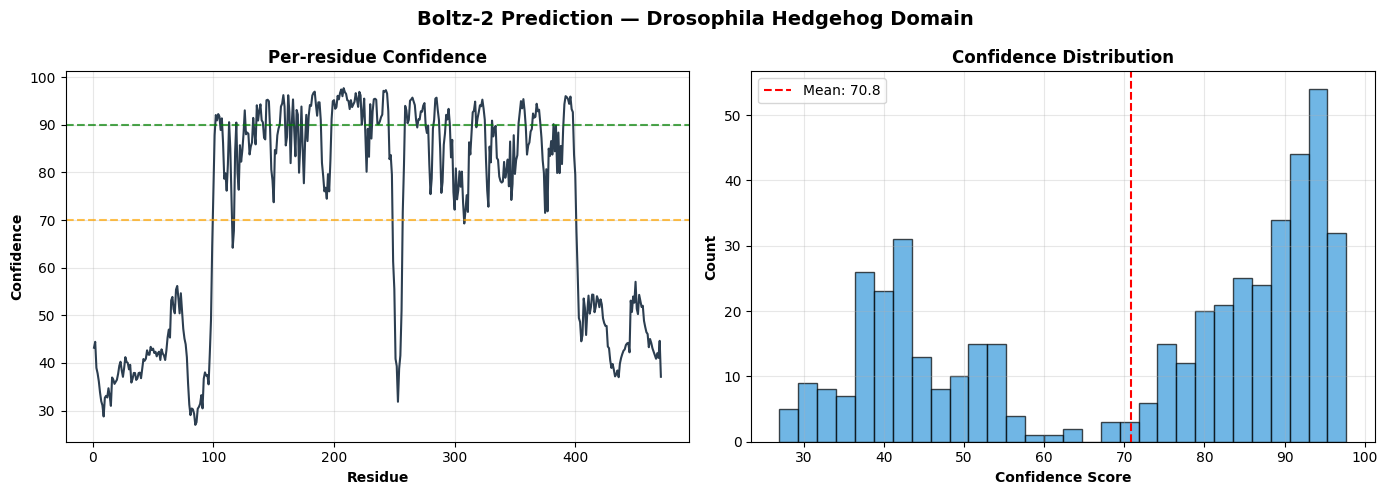

✓ Figure saved: boltz_analysis.png


In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Look for confidence scores
json_files = sorted(glob.glob("boltz_output/**/*confidence*.json", recursive=True))
json_files += sorted(glob.glob("boltz_output/**/*scores*.json", recursive=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Boltz-2 Prediction — Drosophila Hedgehog Domain",
             fontweight='bold', fontsize=14)

if json_files:
    with open(json_files[0]) as f:
        scores = json.load(f)
    print("Confidence scores:", json.dumps(scores, indent=2)[:500])

# If we have a PDB/CIF, extract B-factors as confidence
if struct_files:
    from Bio.PDB import PDBParser, MMCIFParser

    if struct_file.endswith(".cif"):
        p = MMCIFParser(QUIET=True)
    else:
        p = PDBParser(QUIET=True)

    structure = p.get_structure("boltz", struct_file)

    # Extract per-residue confidence from B-factors
    confidence = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[0] == ' ':
                    for atom in residue:
                        if atom.name == 'CA':
                            confidence.append(atom.get_bfactor())
                            break

    if confidence:
        confidence = np.array(confidence)

        # Plot confidence per residue
        axes[0].plot(range(1, len(confidence)+1), confidence,
                    color='#2c3e50', linewidth=1.5)
        axes[0].axhline(y=70, color='orange', linestyle='--', alpha=0.7)
        axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7)
        axes[0].set_xlabel("Residue", fontweight='bold')
        axes[0].set_ylabel("Confidence", fontweight='bold')
        axes[0].set_title("Per-residue Confidence", fontweight='bold')
        axes[0].grid(True, alpha=0.3)

        # Confidence distribution
        axes[1].hist(confidence, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[1].axvline(x=np.mean(confidence), color='red', linestyle='--',
                       label=f'Mean: {np.mean(confidence):.1f}')
        axes[1].set_xlabel("Confidence Score", fontweight='bold')
        axes[1].set_ylabel("Count", fontweight='bold')
        axes[1].set_title("Confidence Distribution", fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("boltz_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure saved: boltz_analysis.png")


In [12]:

!cp boltz_analysis.png boltz_output/
!zip -r -q boltz_results.zip boltz_output/

from google.colab import files
files.download("boltz_results.zip")
print("✓ Download complete")






<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download complete
